# Sampling Analysis


## Imports


In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from src.workflow_config import discover_structure_files
from src.sampling_analysis_utils import energies, force_norms_by_species, load_traj


## Full dataset (reference)


In [7]:
analysis_roots = [Path("data")]  # replace with the directories for the system you want to analyze
patterns = ["vasprun*.xml", "XDATCAR*", "*.xyz", "*.extxyz"]
vasp_files = discover_structure_files(analysis_roots, patterns=patterns, recursive=True)
print(f"Found {len(vasp_files)} input files across {len(analysis_roots)} analysis roots.")

# Read all structures from the input files with ASE
full = load_traj(vasp_files)
print(f"Total number of structures read: {len(full)}")


Found 1 input files across 1 analysis roots.
Total number of structures read: 1232


## Sampled dataset


In [8]:
selected_dir = Path("selected")
method_trajs = {
    "FPS": selected_dir / "FPS_selected.traj",
    "Random": selected_dir / "Random_selected.traj",
}

if method_trajs["FPS"].exists():
    sampl = load_traj(method_trajs["FPS"])
elif method_trajs["Random"].exists():
    sampl = load_traj(method_trajs["Random"])
else:
    raise FileNotFoundError("No sampled trajectory found in ./selected.")

print(f"Number of sampled structures: {len(sampl)}")


Number of sampled structures: 1178


## Energy and force analysis


Average energy (full): -914.8614633357955 eV


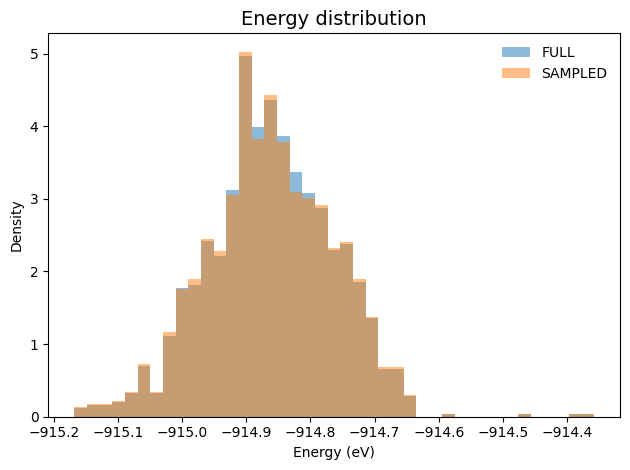

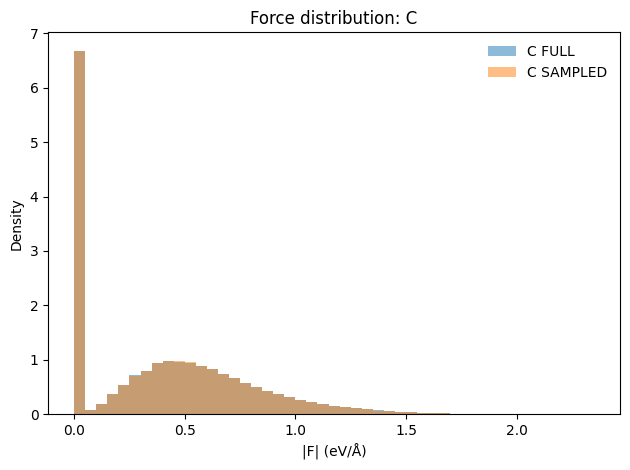

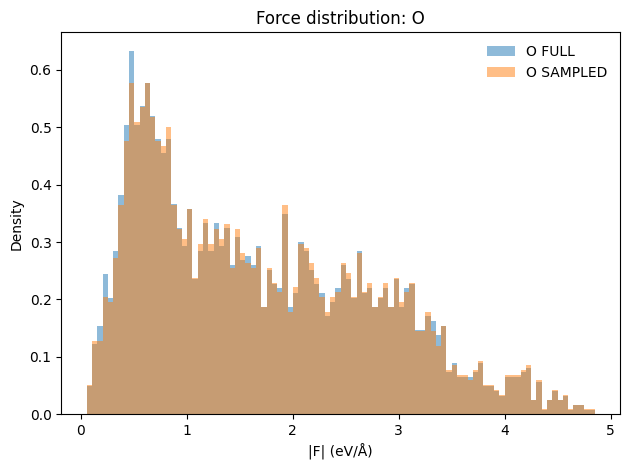

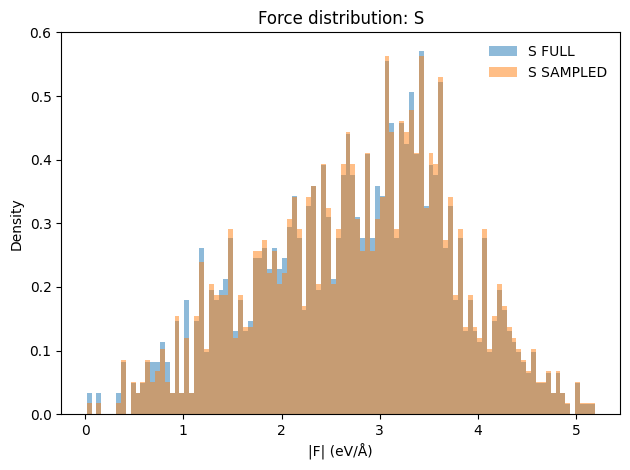

In [9]:
# --- Energies (per structure)
E_full = energies(full)
E_full_mean = np.mean(E_full)
print(f"Average energy (full): {E_full_mean} eV")
E_samp = energies(sampl)

bin_width_en = 0.02  # eV
arr = np.concatenate([E_full[~np.isnan(E_full)], E_samp[~np.isnan(E_samp)]])
lo, hi = arr.min(), arr.max()
n_bins = max(1, int(np.ceil((hi - lo) / bin_width_en)))
edges = np.linspace(lo, hi, n_bins + 1)

plt.figure()
plt.hist(E_full[~np.isnan(E_full)], bins=edges, alpha=0.5, label="FULL", density=True)
plt.hist(E_samp[~np.isnan(E_samp)], bins=edges, alpha=0.5, label="SAMPLED", density=True)
plt.xlabel("Energy (eV)"); plt.ylabel("Density")
plt.title("Energy distribution", fontsize=14)
plt.legend(frameon=False); plt.tight_layout(); plt.show()

# --- Forces (per atom, by species)
F_full = force_norms_by_species(full)
F_samp = force_norms_by_species(sampl)

bin_width_f = 0.05  # eV/Å
for species in sorted(set(F_full) | set(F_samp)):
    arr = []
    if species in F_full:
        arr.append(F_full[species])
    if species in F_samp:
        arr.append(F_samp[species])
    arr = np.concatenate(arr)
    lo, hi = arr.min(), arr.max()
    n_bins = max(1, int(np.ceil((hi - lo) / bin_width_f)))
    edges = np.linspace(lo, hi, n_bins + 1)

    plt.figure()
    if species in F_full:
        plt.hist(F_full[species], bins=edges, alpha=0.5, label=f"{species} FULL", density=True)
    if species in F_samp:
        plt.hist(F_samp[species], bins=edges, alpha=0.5, label=f"{species} SAMPLED", density=True)
    plt.xlabel("|F| (eV/Å)"); plt.ylabel("Density")
    plt.title(f"Force distribution: {species}")
    plt.legend(frameon=False); plt.tight_layout(); plt.show()


In [10]:
# --- Sampling summary metrics (energies + forces)
n_full = len(full)
n_samp = len(sampl)
pct_samp = 100.0 * n_samp / n_full if n_full else 0.0
print(f"Sampled structures: {n_samp}/{n_full} ({pct_samp:.2f}%)")

def _coverage_minmax(full_vals: np.ndarray, samp_vals: np.ndarray) -> float:
    f = full_vals[~np.isnan(full_vals)]
    s = samp_vals[~np.isnan(samp_vals)]
    if len(f) == 0 or len(s) == 0:
        return np.nan
    fmin, fmax = np.min(f), np.max(f)
    smin, smax = np.min(s), np.max(s)
    frange = fmax - fmin
    if frange <= 0:
        return np.nan
    covered = max(0.0, min(smax, fmax) - max(smin, fmin))
    return covered / frange

def _stats(vals: np.ndarray, name: str):
    v = vals[~np.isnan(vals)]
    if len(v) == 0:
        print(f"{name}: no data")
        return
    qs = np.quantile(v, [0.05, 0.5, 0.95])
    print(f"{name}: min={v.min():.6g}, max={v.max():.6g}, mean={v.mean():.6g}, std={v.std():.6g}, q05={qs[0]:.6g}, q50={qs[1]:.6g}, q95={qs[2]:.6g}")

# Energy coverage and stats
cov_E = _coverage_minmax(E_full, E_samp)
print(f"Energy range coverage (sample vs full): {cov_E:.2%}")
_stats(E_full, "E_full")
_stats(E_samp, "E_samp")

# Force coverage and stats by species
print("Force norm coverage by species:")
for species in sorted(set(F_full) | set(F_samp)):
    f_full = F_full.get(species, np.array([], dtype=float))
    f_samp = F_samp.get(species, np.array([], dtype=float))
    cov_F = _coverage_minmax(f_full, f_samp)
    print(f"  {species}: coverage={cov_F:.2%}")
    _stats(f_full, f"F_full[{species}]")
    _stats(f_samp, f"F_samp[{species}]")


Sampled structures: 1178/1232 (95.62%)
Energy range coverage (sample vs full): 100.00%
E_full: min=-915.168, max=-914.358, mean=-914.861, std=0.0985015, q05=-915.016, q50=-914.862, q95=-914.705
E_samp: min=-915.168, max=-914.358, mean=-914.862, std=0.0997634, q05=-915.018, q50=-914.864, q95=-914.704
Force norm coverage by species:
  C: coverage=100.00%
F_full[C]: min=0.000269687, max=2.34944, mean=0.407767, std=0.375514, q05=0.0042871, q50=0.383896, q95=1.09335
F_samp[C]: min=0.000280591, max=2.34944, mean=0.407978, std=0.375508, q05=0.00433113, q50=0.384682, q95=1.09331
  O: coverage=100.00%
F_full[O]: min=0.0544359, max=4.84908, mean=1.68913, std=1.08159, q05=0.343885, q50=1.48237, q95=3.65839
F_samp[O]: min=0.0544359, max=4.84908, mean=1.70325, std=1.08008, q05=0.355066, q50=1.49565, q95=3.69606
  S: coverage=99.78%
F_full[S]: min=0.016848, max=5.1862, mean=2.75104, std=0.993429, q05=1.02673, q50=2.85892, q95=4.28675
F_samp[S]: min=0.0280811, max=5.1862, mean=2.77963, std=0.982719, 